# Import library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import string
import joblib

from nltk.corpus import stopwords 
from nltk.stem.porter import PorterStemmer
from wordcloud import WordCloud
from collections import Counter
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score


# Data setup

In [2]:
#Path of the file to read 
file_malware = 'dataset/raw/malware.csv'
df = pd.read_csv(file_malware)
#Load dataset
df.head()

,hash,millisecond,classification,state,usage_counter,prio,static_prio,normal_prio,policy,vm_pgoff,...,nivcsw,min_flt,maj_flt,fs_excl_counter,lock,utime,stime,gtime,cgtime,signal_nvcsw
0,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,0,malware,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0
1,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,1,malware,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0
2,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,2,malware,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0
3,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,3,malware,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0
4,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,4,malware,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0


In [3]:
#check data set info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 35 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   hash               100000 non-null  str  
 1   millisecond        100000 non-null  int64
 2   classification     100000 non-null  str  
 3   state              100000 non-null  int64
 4   usage_counter      100000 non-null  int64
 5   prio               100000 non-null  int64
 6   static_prio        100000 non-null  int64
 7   normal_prio        100000 non-null  int64
 8   policy             100000 non-null  int64
 9   vm_pgoff           100000 non-null  int64
 10  vm_truncate_count  100000 non-null  int64
 11  task_size          100000 non-null  int64
 12  cached_hole_size   100000 non-null  int64
 13  free_area_cache    100000 non-null  int64
 14  mm_users           100000 non-null  int64
 15  map_count          100000 non-null  int64
 16  hiwater_rss        100000 non-null  int64
 17  tot

In [4]:
df.describe()

,millisecond,state,usage_counter,prio,static_prio,normal_prio,policy,vm_pgoff,vm_truncate_count,task_size,...,nivcsw,min_flt,maj_flt,fs_excl_counter,lock,utime,stime,gtime,cgtime,signal_nvcsw
count,100000.000000,1.000000e+05,100000.0,1.000000e+05,100000.000000,100000.0,100000.0,100000.0,100000.000000,100000.0,...,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.00000,100000.0,100000.0
mean,499.500000,1.577683e+05,0.0,3.069706e+09,18183.900070,0.0,0.0,0.0,15312.739510,0.0,...,32.991160,2.053130,117.920240,1.109190,3.204448e+09,385415.451970,4.059310,1.66142,0.0,0.0
std,288.676434,9.361726e+05,0.0,2.963061e+05,4609.792765,0.0,0.0,0.0,3256.475008,0.0,...,52.730176,13.881382,3.116892,2.160466,0.000000e+00,10144.036494,0.822848,3.26304,0.0,0.0
min,0.000000,0.000000e+00,0.0,3.069190e+09,13988.000000,0.0,0.0,0.0,9695.000000,0.0,...,0.000000,0.000000,112.000000,0.000000,3.204448e+09,371782.000000,3.000000,0.00000,0.0,0.0
25%,249.750000,0.000000e+00,0.0,3.069446e+09,14352.000000,0.0,0.0,0.0,12648.000000,0.0,...,1.000000,0.000000,114.000000,0.000000,3.204448e+09,378208.000000,3.000000,0.00000,0.0,0.0
50%,499.500000,0.000000e+00,0.0,3.069698e+09,16159.000000,0.0,0.0,0.0,15245.000000,0.0,...,9.000000,1.000000,120.000000,0.000000,3.204448e+09,383637.000000,4.000000,0.00000,0.0,0.0
75%,749.250000,4.096000e+03,0.0,3.069957e+09,22182.000000,0.0,0.0,0.0,17663.000000,0.0,...,46.000000,1.000000,120.000000,1.000000,3.204448e+09,390324.000000,5.000000,1.00000,0.0,0.0
max,999.000000,4.326605e+07,0.0,3.070222e+09,31855.000000,0.0,0.0,0.0,27157.000000,0.0,...,365.000000,256.000000,120.000000,18.000000,3.204448e+09,421913.000000,7.000000,15.00000,0.0,0.0


# Data Visulization

In [5]:
df.head()

,hash,millisecond,classification,state,usage_counter,prio,static_prio,normal_prio,policy,vm_pgoff,...,nivcsw,min_flt,maj_flt,fs_excl_counter,lock,utime,stime,gtime,cgtime,signal_nvcsw
0,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,0,malware,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0
1,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,1,malware,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0
2,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,2,malware,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0
3,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,3,malware,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0
4,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,4,malware,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0


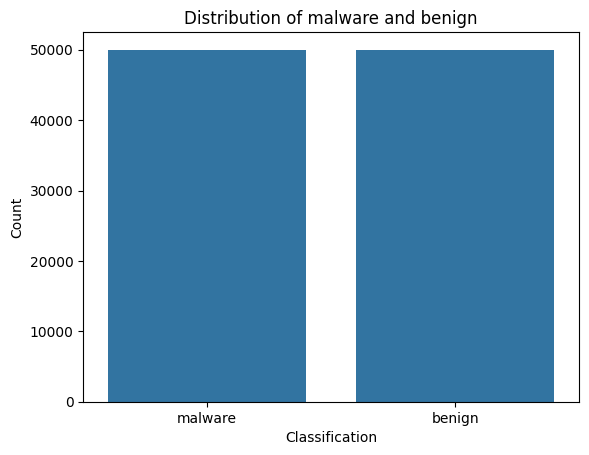

In [6]:
#bar chart: distribution visualization of malware and benign
sns.countplot(x=df['classification'])
plt.title("Distribution of malware and benign")
plt.xlabel("Classification")
plt.ylabel("Count")
plt.show()


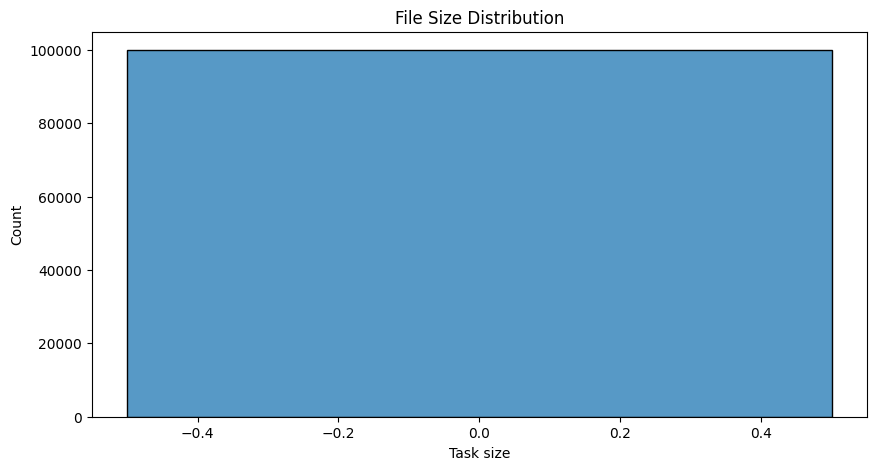

In [7]:
#File size distribution: Compare malware vs. benign with histograms 
plt.figure(figsize=(10,5))
sns.histplot(x=df['task_size'])
plt.xlabel('Task size')
plt.ylabel('Count')
plt.title("File Size Distribution")
plt.show()

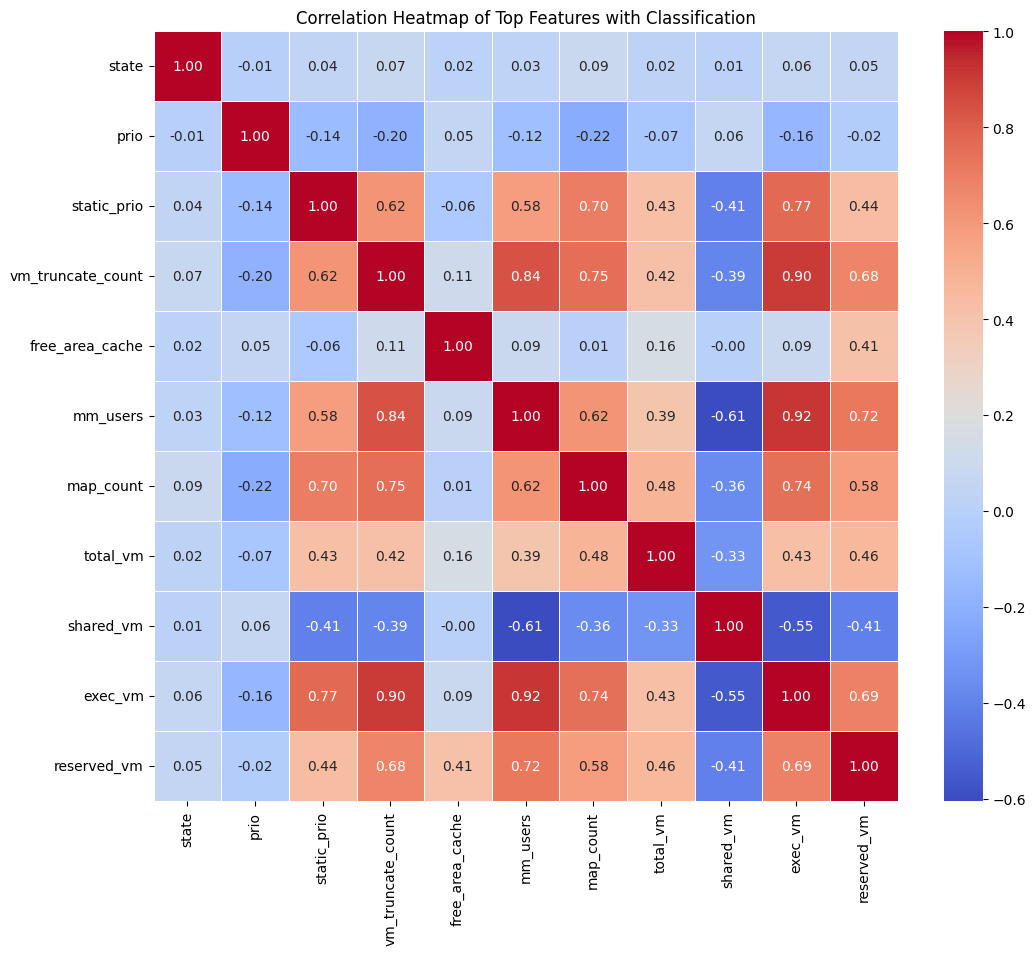

In [8]:
df_corr = df.copy()
df_corr['classification_num'] = np.where(df_corr['classification'] == 'malware', 1, 0)

numeric_df = df_corr.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

top_features = corr_matrix.index[abs(corr_matrix['classification_num']) > 0.05].tolist()
top_features = top_features[:11]

plt.figure(figsize=(12, 10))
sns.heatmap(df_corr[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Top Features with Classification')
plt.show()


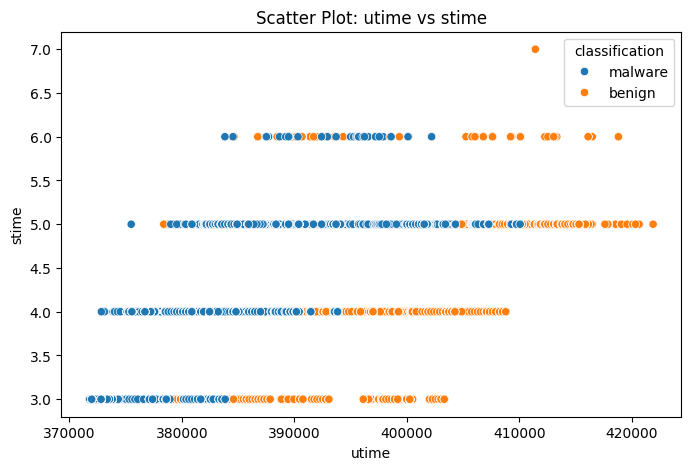

In [9]:
# Add scatter plot and complete EDA section
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='utime', y='stime', hue='classification')
plt.title('Scatter Plot: utime vs stime')
plt.show()

# Data cleaning

In [10]:
df.head()

,hash,millisecond,classification,state,usage_counter,prio,static_prio,normal_prio,policy,vm_pgoff,...,nivcsw,min_flt,maj_flt,fs_excl_counter,lock,utime,stime,gtime,cgtime,signal_nvcsw
0,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,0,malware,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0
1,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,1,malware,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0
2,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,2,malware,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0
3,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,3,malware,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0
4,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,4,malware,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0


In [11]:
# benign is labeled as 0 and malware is labeled as 1
df['classification'] = df['classification'].map({'benign': 0, 'malware': 1})

In [12]:
#check to ensure the data is labeled
df['classification'].value_counts()

classification
1    50000
0    50000
Name: count, dtype: int64

In [13]:
#check and handling missing values in dataset
df.isnull().sum()

hash                 0
millisecond          0
classification       0
state                0
usage_counter        0
prio                 0
static_prio          0
normal_prio          0
policy               0
vm_pgoff             0
vm_truncate_count    0
task_size            0
cached_hole_size     0
free_area_cache      0
mm_users             0
map_count            0
hiwater_rss          0
total_vm             0
shared_vm            0
exec_vm              0
reserved_vm          0
nr_ptes              0
end_data             0
last_interval        0
nvcsw                0
nivcsw               0
min_flt              0
maj_flt              0
fs_excl_counter      0
lock                 0
utime                0
stime                0
gtime                0
cgtime               0
signal_nvcsw         0
dtype: int64

In [14]:
# checking for duplicate
print("Total rows:", len(df))
print("Duplicated rows:", df.duplicated().sum())

# % duplicated
print(f"% duplicated: {df.duplicated().sum()/len(df)*100:.2f}%")

Total rows: 100000
Duplicated rows: 0
% duplicated: 0.00%


In [15]:
#check data set info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 35 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   hash               100000 non-null  str  
 1   millisecond        100000 non-null  int64
 2   classification     100000 non-null  int64
 3   state              100000 non-null  int64
 4   usage_counter      100000 non-null  int64
 5   prio               100000 non-null  int64
 6   static_prio        100000 non-null  int64
 7   normal_prio        100000 non-null  int64
 8   policy             100000 non-null  int64
 9   vm_pgoff           100000 non-null  int64
 10  vm_truncate_count  100000 non-null  int64
 11  task_size          100000 non-null  int64
 12  cached_hole_size   100000 non-null  int64
 13  free_area_cache    100000 non-null  int64
 14  mm_users           100000 non-null  int64
 15  map_count          100000 non-null  int64
 16  hiwater_rss        100000 non-null  int64
 17  tot

In [16]:
#check the column of data 
df.columns

Index(['hash', 'millisecond', 'classification', 'state', 'usage_counter',
       'prio', 'static_prio', 'normal_prio', 'policy', 'vm_pgoff',
       'vm_truncate_count', 'task_size', 'cached_hole_size', 'free_area_cache',
       'mm_users', 'map_count', 'hiwater_rss', 'total_vm', 'shared_vm',
       'exec_vm', 'reserved_vm', 'nr_ptes', 'end_data', 'last_interval',
       'nvcsw', 'nivcsw', 'min_flt', 'maj_flt', 'fs_excl_counter', 'lock',
       'utime', 'stime', 'gtime', 'cgtime', 'signal_nvcsw'],
      dtype='str')

In [17]:
# remove useless columns
df = df.drop(
    columns = [
        'hash',
        'usage_counter', 
        'normal_prio',
        'policy',
        'vm_pgoff',
        'task_size',
        'cached_hole_size',
        'hiwater_rss',
        'nr_ptes',
        'lock',
        'cgtime',
        'signal_nvcsw'
    ],
)

In [18]:
#check column again
df.columns

Index(['millisecond', 'classification', 'state', 'prio', 'static_prio',
       'vm_truncate_count', 'free_area_cache', 'mm_users', 'map_count',
       'total_vm', 'shared_vm', 'exec_vm', 'reserved_vm', 'end_data',
       'last_interval', 'nvcsw', 'nivcsw', 'min_flt', 'maj_flt',
       'fs_excl_counter', 'utime', 'stime', 'gtime'],
      dtype='str')

In [19]:
df.shape

(100000, 23)

In [20]:
df.head()

,millisecond,classification,state,prio,static_prio,vm_truncate_count,free_area_cache,mm_users,map_count,total_vm,...,end_data,last_interval,nvcsw,nivcsw,min_flt,maj_flt,fs_excl_counter,utime,stime,gtime
0,0,1,0,3069378560,14274,13173,24,724,6850,150,...,120,3473,341974,0,0,120,0,380690,4,0
1,1,1,0,3069378560,14274,13173,24,724,6850,150,...,120,3473,341974,0,0,120,0,380690,4,0
2,2,1,0,3069378560,14274,13173,24,724,6850,150,...,120,3473,341974,0,0,120,0,380690,4,0
3,3,1,0,3069378560,14274,13173,24,724,6850,150,...,120,3473,341974,0,0,120,0,380690,4,0
4,4,1,0,3069378560,14274,13173,24,724,6850,150,...,120,3473,341974,0,0,120,0,380690,4,0


In [21]:
# save the processed file
df.to_csv('dataset/processed/processed_malware.csv', index=False)

# Feature Extraction

In [22]:
#use all columns except classification as X and column classification as y
X = df.drop("classification", axis=1) 
y = df["classification"]               

X.head()

,millisecond,state,prio,static_prio,vm_truncate_count,free_area_cache,mm_users,map_count,total_vm,shared_vm,...,end_data,last_interval,nvcsw,nivcsw,min_flt,maj_flt,fs_excl_counter,utime,stime,gtime
0,0,0,3069378560,14274,13173,24,724,6850,150,120,...,120,3473,341974,0,0,120,0,380690,4,0
1,1,0,3069378560,14274,13173,24,724,6850,150,120,...,120,3473,341974,0,0,120,0,380690,4,0
2,2,0,3069378560,14274,13173,24,724,6850,150,120,...,120,3473,341974,0,0,120,0,380690,4,0
3,3,0,3069378560,14274,13173,24,724,6850,150,120,...,120,3473,341974,0,0,120,0,380690,4,0
4,4,0,3069378560,14274,13173,24,724,6850,150,120,...,120,3473,341974,0,0,120,0,380690,4,0


In [23]:
#scale features into the range from 0 to 1
scaler = MinMaxScaler()

#split into training (70%) and test (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

#apply scaling to to all feature in X
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model Training

In [24]:
#Model 1 -  Logistic Regeression
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9344333333333333
[[13728  1272]
 [  695 14305]]
              precision    recall  f1-score   support

           0       0.95      0.92      0.93     15000
           1       0.92      0.95      0.94     15000

    accuracy                           0.93     30000
   macro avg       0.94      0.93      0.93     30000
weighted avg       0.94      0.93      0.93     30000



In [25]:
#Model 2 — Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=8
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9997333333333334
[[15000     0]
 [    8 14992]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15000
           1       1.00      1.00      1.00     15000

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000



In [26]:
#show the accuracy of the each model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

accuracy_rf = accuracy_score(y_test, y_pred_rf) 
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_lr, accuracy_rf]
})

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_lr, accuracy_rf],
    "Precision": [precision_lr, precision_rf],
    "Recall": [recall_lr, recall_rf],
    "F1-score": [f1_lr, f1_rf]
})

print("\n--- Model Comparison ---")
print(comparison)


--- Model Comparison ---
                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.934433   0.918341  0.953667  0.935671
1        Random Forest  0.999733   1.000000  0.999467  0.999733


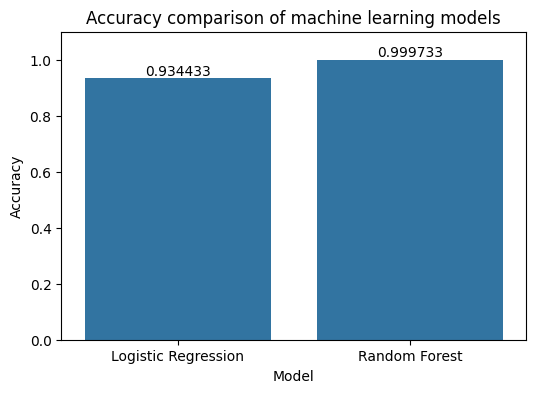

In [27]:
#visulization for accuracy comparision
plt.figure(figsize=(6,4))

ax = sns.barplot(x="Model", y="Accuracy", data=comparison)

for container in ax.containers:
    ax.bar_label(container, fmt="%.6f")

plt.title("Accuracy comparison of machine learning models")
plt.ylim(0,1.1)

plt.show()

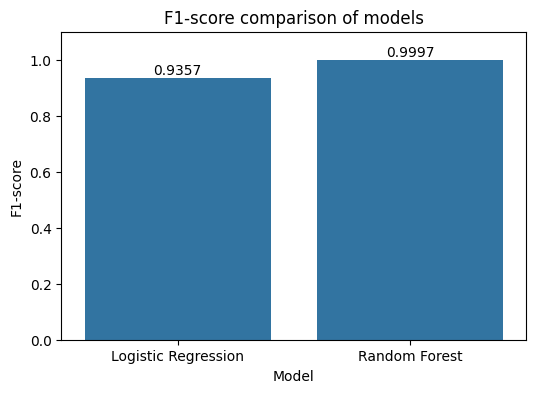

In [28]:
#visulization for F1-score comparision
plt.figure(figsize=(6,4))

ax = sns.barplot(x="Model", y="F1-score", data=comparison)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f")

plt.title("F1-score comparison of models")
plt.ylim(0,1.1)

plt.show()

# Save Model

In [29]:
joblib.dump(rf, "backend/model/malware_rf_model.pkl") #save model random forest
joblib.dump(scaler, 'backend/model/scaler.pkl')

['backend/model/scaler.pkl']

In [30]:
#test model
sample = np.array([X_test[0]])
prediction = rf.predict(sample)

print("Prediction:", prediction)

Prediction: [1]
